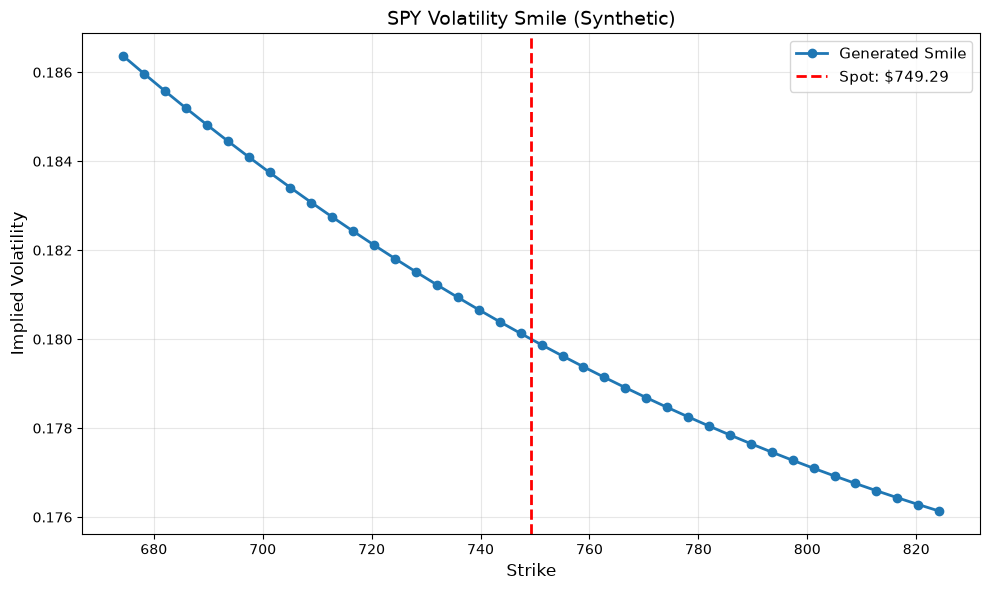

ATM IV: 0.1799
OTM Put IV (90% strike): 0.1864
OTM Call IV (110% strike): 0.1761
Skew: 0.0102


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.stats import norm

def generate_synthetic_smile(spot, strikes, dte, atm_vol=0.18, skew=-0.05, convexity=0.1):
    """
    Generate realistic volatility smile using SVI-inspired model.
    
    Parameters:
    - spot: current price
    - strikes: array of strike prices
    - dte: days to expiration
    - atm_vol: at-the-money volatility
    - skew: smile skew (negative = puts more expensive)
    - convexity: smile curvature
    """
    moneyness = np.log(strikes / spot)
    skew_effect = skew * moneyness
    smile_effect = convexity * moneyness**2
    term_decay = np.exp(-dte / 365)
    iv = atm_vol + skew_effect + smile_effect * term_decay
    return np.clip(iv, 0.05, 2.0)  

spot = 749.29
dte = 3  
strikes = np.linspace(spot * 0.90, spot * 1.10, 40)  
ivs = generate_synthetic_smile(spot, strikes, dte)

plt.figure(figsize=(10, 6))
plt.plot(strikes, ivs, 'o-', linewidth=2, markersize=6, label='Generated Smile')
plt.axvline(spot, color='red', linestyle='--', linewidth=2, label=f'Spot: ${spot:.2f}')
plt.xlabel('Strike', fontsize=12)
plt.ylabel('Implied Volatility', fontsize=12)
plt.title('SPY Volatility Smile (Synthetic)', fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"ATM IV: {ivs[len(ivs)//2]:.4f}")
print(f"OTM Put IV (90% strike): {ivs[0]:.4f}")
print(f"OTM Call IV (110% strike): {ivs[-1]:.4f}")
print(f"Skew: {ivs[0] - ivs[-1]:.4f}")